# Chapter 17 -- Loops, Goals, and Iterations: Agents, Skills, and Hooks

This notebook makes the chapter's methodology concrete and runnable. The chapter argues that the primary unit of design for an LLM system is the **loop** -- observe, propose, act, evaluate, revise -- driven by an explicit **goal** and guarded by **hooks** (checkable success gates). Here we build one reusable loop harness and plug three problems into it: a derivative-free root finder, the *same* loop repurposed as an IRR solver, and a credit-risk expected-loss stress engine. The numerical problems are only *vehicles*; the lesson is the loop and the hook. All credit figures are illustrative and hypothetical.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Concept 1 -- A generic goal-directed loop harness

`run_loop` implements the five phases from the chapter. It is the reusable spine every example below plugs into: swap the `propose` / `act` / `evaluate` / `is_done` callbacks and the *same* loop drives a different task. It returns a trace (one record per iteration) and a status: `'converged'` when the success gate fires, `'budget_exhausted'` when the iteration budget runs out (the guaranteed-terminating stopping rule).

In [2]:
def run_loop(initial_state, propose, act, evaluate, is_done,
             max_iters, on_stop=None):
    """Generic goal-directed iteration loop.

    Implements the chapter's five phases:

    1. Observe  -- read the current state at the top of each pass.
    2. Propose  -- ``propose(state)`` returns a candidate action.
    3. Act      -- ``act(state, action)`` applies it, returning the new state.
    4. Evaluate -- ``evaluate(state)`` returns feedback (e.g. a residual),
                   merged into the state so the next Propose can see it.
    5. Revise   -- if ``is_done(state)`` is False and budget remains, loop
                   again, folding the feedback forward.

    Parameters
    ----------
    initial_state : dict
        Starting state. Copied; never mutated in place.
    propose, act, evaluate, is_done : callables
        The four loop callbacks. ``evaluate`` returns a dict merged into
        state; ``is_done`` is the success predicate (the tolerance hook).
    max_iters : int
        Iteration budget -- the guaranteed-terminating stopping rule.
    on_stop : callable, optional
        Called once as ``on_stop(state, status, trace)`` when the loop ends.

    Returns
    -------
    trace : list of dict
        One record per iteration (state snapshot plus ``iter`` and ``action``).
    status : str
        ``'converged'`` if the success gate fired, else ``'budget_exhausted'``.
    """
    state = dict(initial_state)
    state.update(evaluate(state))          # initial residual on record
    trace, status = [], 'budget_exhausted'
    if is_done(state):                     # already at the goal: do not act
        rec = dict(state); rec['iter'], rec['action'] = 0, None
        trace.append(rec)
        if on_stop is not None:
            on_stop(state, 'converged', trace)
        return trace, 'converged'
    for it in range(1, max_iters + 1):
        action = propose(state)            # Propose
        state = act(state, action)         # Act
        state.update(evaluate(state))      # Evaluate
        record = dict(state)
        record['iter'], record['action'] = it, action
        trace.append(record)
        if is_done(state):                 # Revise / stop
            status = 'converged'
            break
    if on_stop is not None:
        on_stop(state, status, trace)
    return trace, status

## Concept 2 -- Derivative-free, sign-guided root finding + the tolerance hook

We solve `f(x) = x**3 - x - 2 = 0` to a tolerance `|f(x)| < 1e-3` (true root x ~ 1.5213797). The solver is **derivative-free**: it only ever *evaluates* `f` and moves its guess by the **sign** of the residual (a regula-falsi / bisection flavour). `within_tolerance` is the **hook** -- the success gate the loop cannot bypass. This mirrors the chapter: the loop reaches tolerance using feedback alone, with no update formula handed to it.

In [3]:
def f(x):
    """Target function for the root-finding demo."""
    return x**3 - x - 2


def within_tolerance(value, tol=1e-3):
    """Success-gate HOOK: True iff |value| is below tolerance."""
    return abs(value) < tol


def make_solver(func, tol=1e-3):
    """Build (propose, act, evaluate, is_done) for a sign-guided bracket search.

    Derivative-free: uses only evaluations of ``func`` and the sign of the
    residual (regula falsi with an Illinois safeguard so the bracket always
    shrinks). Plugs straight into ``run_loop``.
    """
    def propose(s):
        # bracket must straddle a sign change for false position to be valid
        if s['flo'] * s['fhi'] > 0:
            raise ValueError('bracket endpoints must have opposite signs')
        # false-position point: where the secant through the bracket hits zero
        return s['hi'] - s['fhi'] * (s['hi'] - s['lo']) / (s['fhi'] - s['flo'])

    def act(s, x):
        s = dict(s)
        fx = func(x)
        if (fx < 0) == (s['flo'] < 0):     # same sign as low end -> move lo up
            if s['side'] == 'lo':
                s['fhi'] *= 0.5            # Illinois: down-weight stale end
            s['lo'], s['flo'], s['side'] = x, fx, 'lo'
        else:                              # opposite sign -> move hi down
            if s['side'] == 'hi':
                s['flo'] *= 0.5
            s['hi'], s['fhi'], s['side'] = x, fx, 'hi'
        s['x'], s['fx'] = x, fx
        return s

    def evaluate(s):
        return {'residual': abs(s['fx'])}

    def is_done(s):
        return within_tolerance(s['fx'], tol)

    return propose, act, evaluate, is_done

Start from a deliberately poor bracket `[0, 2]` and run the loop. The trace shows the residual `|f(x)|` shrinking until the tolerance hook passes.

In [4]:
lo, hi = 0.0, 2.0
init = {'lo': lo, 'hi': hi, 'flo': f(lo), 'fhi': f(hi),
        'x': lo, 'fx': f(lo), 'side': None}
propose, act, evaluate, is_done = make_solver(f, tol=1e-3)
trace, status = run_loop(init, propose, act, evaluate, is_done, max_iters=12)

root_df = pd.DataFrame(trace)[['iter', 'x', 'fx', 'residual']]
print(root_df.to_string(index=False))
print(f"\nstatus = {status}; root ~ {trace[-1]['x']:.5f}; "
      f"|f| = {trace[-1]['residual']:.2e}")
root_df

 iter        x        fx  residual
    1 0.666667 -2.370370  2.370370
    2 1.162791 -1.590602  1.590602
    3 1.533666  0.073720  0.073720
    4 1.517239 -0.024535  0.024535
    5 1.521341 -0.000231  0.000231

status = converged; root ~ 1.52134; |f| = 2.31e-04


,iter,x,fx,residual
0,1,0.666667,-2.370370,2.370370
1,2,1.162791,-1.590602,1.590602
2,3,1.533666,0.073720,0.073720
3,4,1.517239,-0.024535,0.024535
4,5,1.521341,-0.000231,0.000231


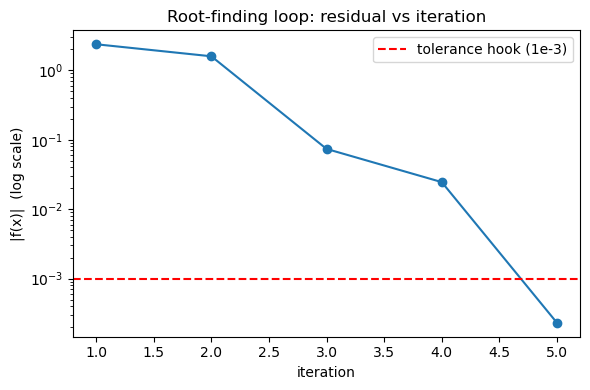

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(root_df['iter'], root_df['residual'], marker='o')
ax.axhline(1e-3, color='red', linestyle='--', label='tolerance hook (1e-3)')
ax.set_xlabel('iteration')
ax.set_ylabel('|f(x)|  (log scale)')
ax.set_title('Root-finding loop: residual vs iteration')
ax.legend()
fig.tight_layout()

### Same loop, finance instance: solve for the IRR

Finding an internal rate of return is mechanically the same problem with `x -> r` and `f -> NPV`. For cash flows `[-100, +60, +60]`, `NPV(r) = -100 + 60/(1+r) + 60/(1+r)**2`; the IRR is the rate with `NPV(r) = 0` (true IRR ~ 0.13066, i.e. 13.07%). We reuse the **identical** `run_loop` and `make_solver`, changing only the function and the tolerance (`|NPV| < 0.05`).

In [6]:
def npv(r, cash_flows=(-100, 60, 60)):
    """NPV of cash flows at rate r (t = 0, 1, 2, ...). Requires r != -1."""
    return sum(c / (1 + r) ** t for t, c in enumerate(cash_flows))


# SAME loop, x -> r and f -> NPV; only the function and tolerance change.
lo, hi = 0.0, 1.0
irr_init = {'lo': lo, 'hi': hi, 'flo': npv(lo), 'fhi': npv(hi),
            'x': lo, 'fx': npv(lo), 'side': None}
p, a, e, d = make_solver(npv, tol=0.05)
irr_trace, irr_status = run_loop(irr_init, p, a, e, d, max_iters=30)

irr_df = pd.DataFrame(irr_trace)[['iter', 'x', 'fx', 'residual']]
irr_df = irr_df.rename(columns={'x': 'r', 'fx': 'NPV'})
print(irr_df.to_string(index=False))

found_r = irr_trace[-1]['x']
print(f"\nstatus = {irr_status}; IRR ~ {found_r:.5f} ({found_r*100:.2f}%); "
      f"NPV = {npv(found_r):.4f}")
assert abs(npv(found_r)) < 0.05, 'IRR not within NPV tolerance'
print("assert passed: |NPV(IRR)| < 0.05  (same loop, x->r, f->NPV)")
irr_df

 iter        r        NPV  residual
    1 0.266667 -15.235457 15.235457
    2 0.151363  -2.626544  2.626544
    3 0.119877   1.419510  1.419510
    4 0.130923  -0.033870  0.033870

status = converged; IRR ~ 0.13092 (13.09%); NPV = -0.0339
assert passed: |NPV(IRR)| < 0.05  (same loop, x->r, f->NPV)


,iter,r,NPV,residual
0,1,0.266667,-15.235457,15.235457
1,2,0.151363,-2.626544,2.626544
2,3,0.119877,1.419510,1.419510
3,4,0.130923,-0.033870,0.033870


## Concept 3 -- A credit-risk expected-loss stress engine

The expected loss on a credit exposure is `EL = PD * LGD * EAD`. We build a tiny engine that computes EL for a base case and a stressed case, then a `decision_gate` -- another **hook**, this time over a business decision. Figures follow the chapter's fictional *Meridian Components* example and are **purely illustrative / hypothetical**: EAD = $40m; base PD = 2.5%, LGD = 40%; stressed PD = 9.0%, LGD = 55%.

In [7]:
def expected_loss(pd_, lgd, ead):
    """Expected credit loss: EL = PD * LGD * EAD. Requires ead > 0 for bps."""
    return pd_ * lgd * ead


def scenario_table(ead, base, stressed):
    """Build a base-vs-stressed expected-loss table.

    ``base`` and ``stressed`` are (PD, LGD) tuples. Returns a DataFrame with
    EL in dollars and in basis points of EAD. All figures are illustrative.
    """
    rows = []
    for name, (pd_, lgd) in [('base', base), ('stressed', stressed)]:
        el = expected_loss(pd_, lgd, ead)
        rows.append({'scenario': name, 'PD': pd_, 'LGD': lgd, 'EAD': ead,
                     'EL_$': el, 'EL_bps': el / ead * 1e4})
    return pd.DataFrame(rows)


EAD = 40e6
el_df = scenario_table(EAD, base=(0.025, 0.40), stressed=(0.09, 0.55))
print(el_df.to_string(index=False))
# reconcile against the chapter's stated (illustrative) figures
assert abs(el_df.loc[0, 'EL_$'] - 0.40e6) < 1.0
assert abs(el_df.loc[1, 'EL_$'] - 1.98e6) < 1.0
assert round(el_df.loc[0, 'EL_bps']) == 100
assert round(el_df.loc[1, 'EL_bps']) == 495
print("\nassert passed: EL = PD*LGD*EAD reconciles (100 bps base, 495 bps stressed)")
el_df

scenario    PD  LGD        EAD      EL_$  EL_bps
    base 0.025 0.40 40000000.0  400000.0   100.0
stressed 0.090 0.55 40000000.0 1980000.0   495.0

assert passed: EL = PD*LGD*EAD reconciles (100 bps base, 495 bps stressed)


,scenario,PD,LGD,EAD,EL_$,EL_bps
0,base,0.025,0.40,40000000.0,400000.0,100.0
1,stressed,0.090,0.55,40000000.0,1980000.0,495.0


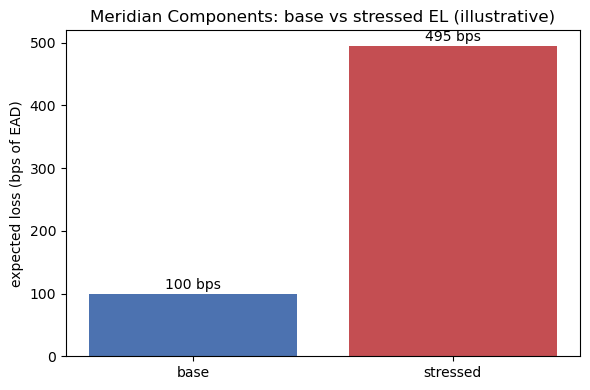

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(el_df['scenario'], el_df['EL_bps'], color=['#4C72B0', '#C44E52'])
for x_, v in zip(el_df['scenario'], el_df['EL_bps']):
    ax.text(x_, v + 8, f"{v:.0f} bps", ha='center')
ax.set_ylabel('expected loss (bps of EAD)')
ax.set_title('Meridian Components: base vs stressed EL (illustrative)')
fig.tight_layout()

In [9]:
def decision_gate(base_bps, stressed_bps, lend_max=150, decline_min=500):
    """Business-decision HOOK over expected loss.

    Returns 'lend' if both base and stressed EL are comfortably low,
    'decline' if the stressed EL is severe, else 'modify' (lend on tighter
    terms). A 'low risk' verdict must be *earned* by arithmetic, not chosen.
    """
    if stressed_bps >= decline_min:
        return 'decline'
    if base_bps <= lend_max and stressed_bps <= lend_max:
        return 'lend'
    return 'modify'


decision = decision_gate(el_df.loc[0, 'EL_bps'], el_df.loc[1, 'EL_bps'])
print(f"base = {el_df.loc[0, 'EL_bps']:.0f} bps, "
      f"stressed = {el_df.loc[1, 'EL_bps']:.0f} bps -> decision: {decision}")
assert decision == 'modify'
print("assert passed: gate returns 'modify' for (100, 495)")

base = 100 bps, stressed = 495 bps -> decision: modify
assert passed: gate returns 'modify' for (100, 495)


## Takeaways

- **The loop is the unit of design.** One `run_loop` harness -- observe, propose, act, evaluate, revise -- drove a root finder, an IRR solver, and (via a different success gate) a credit decision. Only the callbacks changed.
- **The hook is where trust lives.** `within_tolerance` and `decision_gate` are *checkable* success predicates the loop cannot talk its way past; the budget (`max_iters`) guarantees termination.
- **Same loop, new state variable.** `x -> r`, `f -> NPV`: a numerical root finder *is* an IRR solver. The skill is recognising the shared loop.
- All credit figures here are illustrative and hypothetical; `EL = PD * LGD * EAD` reconciles by construction (100 bps base, 495 bps stressed).